In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from rdkit import Chem
from IPython.display import display
from pathlib import Path

import sys
sys.path.append("../scripts/")
from data_utils import dfUtils
from smiles_utils import *

import matplotlib.pyplot as plt
import seaborn as sns

mol to structure converter:
https://www.cheminfo.org/flavor/malaria/Utilities/SMILES_generator___checker/index.html

generated il smiles: CCCCn1cc[n+](C)c1.F[B-](F)(F)F
sanitized cation smiles: CCCCn1cc[n+](C)c1
sanitized anion smiles: F[B-](F)(F)F
sanitized il smiles: CCCCn1cc[n+](C)c1.F[B-](F)(F)F


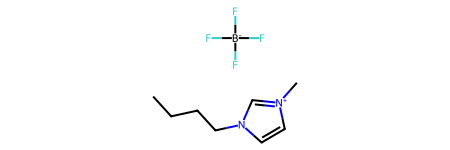

In [3]:
cation_smiles = "CCCCn1cc[n+](C)c1"
anion_smiles = "F[B-](F)(F)F"
il_smiles = cation_smiles + "." + anion_smiles
print(f"generated il smiles: {il_smiles}")

sanitized_cation_smiles = sanitized_smiles(cation_smiles)
print(f"sanitized cation smiles: {sanitized_cation_smiles}")
sanitized_anion_smiles = sanitized_smiles(anion_smiles)
print(f"sanitized anion smiles: {sanitized_anion_smiles}")

sanitized_il_smiles = sanitized_smiles(il_smiles)
print(f"sanitized il smiles: {sanitized_il_smiles}")
mol = Chem.MolFromSmiles(sanitized_il_smiles)
display(mol)

## Scan VISPILS dataset

In [4]:
df = pd.read_csv("../../vispils/data/data_vispils.csv")

df = dfUtils(df)
df.data_summary(il_smiles_col="Iso SMILES", temp_col="Temperature")


====== data summary ======

Total data points (20252)
Unique IL SMILES (2951)
Unique temperatures (25): [253.0, 253.15, 253.2, 258.15, 259.9, 262.61, 262.7, 263.1, 263.15, 263.42, 264.05, 264.25, 264.5, 264.9, 265.1, 265.65, 265.94, 266.6, 266.77, 267.3, 267.59, 268.0, 268.15, 268.41, 269.1]
Columns (12): Index(['Dataset', 'Iso SMILES', 'cSMILES', 'aSMILES', 'Pressure',
       'Temperature', 'Log viscosity', 'Viscosity', 'cfam', 'afam', 'cvolume',
       'avolume'],
      dtype='object')


,Dataset,Iso SMILES,cSMILES,aSMILES,Pressure,Temperature,Log viscosity,Viscosity,cfam,afam,cvolume,avolume
0,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,273.15,2.030195,107.20,,ntf,0.063976,0.155344
1,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,278.15,1.900367,79.50,,ntf,0.063976,0.155344
2,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,283.15,1.782473,60.60,,ntf,0.063976,0.155344
3,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,288.15,1.675778,47.40,,ntf,0.063976,0.155344
4,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,293.15,1.578983,37.93,,ntf,0.063976,0.155344


In [5]:
# sanitize columns of ld data_vispils.csv
df.sanitize_old_df(inplace=True)
df.data_summary(il_smiles_col="sanitized_il_smiles", temp_col="temperature_k")

Renaming 12 columns: ['Dataset', 'Iso SMILES', 'cSMILES', 'aSMILES', 'Pressure', 'Temperature', 'Viscosity', 'Log viscosity', 'cfam', 'afam', 'cvolume', 'avolume']

====== data summary ======

Total data points (20252)
Unique IL SMILES (2951)
Unique temperatures (25): [253.0, 253.15, 253.2, 258.15, 259.9, 262.61, 262.7, 263.1, 263.15, 263.42, 264.05, 264.25, 264.5, 264.9, 265.1, 265.65, 265.94, 266.6, 266.77, 267.3, 267.59, 268.0, 268.15, 268.41, 269.1]
Columns (12): Index(['reference', 'sanitized_il_smiles', 'cation_smiles', 'anion_smiles',
       'pressure_atm', 'temperature_k', 'log_10_viscosity_mpas',
       'viscosity_mpas', 'cation_family', 'anion_family',
       'cation_volume_rdkit', 'anion_volume_rdkit'],
      dtype='object')


,reference,sanitized_il_smiles,cation_smiles,anion_smiles,pressure_atm,temperature_k,log_10_viscosity_mpas,viscosity_mpas,cation_family,anion_family,cation_volume_rdkit,anion_volume_rdkit
0,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,273.15,2.030195,107.20,,ntf,0.063976,0.155344
1,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,278.15,1.900367,79.50,,ntf,0.063976,0.155344
2,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,283.15,1.782473,60.60,,ntf,0.063976,0.155344
3,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,288.15,1.675778,47.40,,ntf,0.063976,0.155344
4,ILthermo,CN(C)C=O.O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,CN(C)C=O,O=S(=O)([N-]S(=O)(=O)C(F)(F)F)C(F)(F)F,0.10135,293.15,1.578983,37.93,,ntf,0.063976,0.155344


In [85]:
# Query data for the specific IL SMILES
df_query = df[df["sanitized_il_smiles"]==sanitized_il_smiles]
df_query = dfUtils(df_query)
df_query.data_summary(il_smiles_col="sanitized_il_smiles", temp_col="temperature_k")


====== data summary ======

Total data points (31)
Unique IL SMILES (1)
Unique temperatures (25): [273.15, 278.15, 283.15, 288.15, 293.15, 294.2, 297.0, 298.15, 303.15, 308.15, 310.0, 313.15, 318.15, 322.0, 323.15, 328.15, 330.0, 331.56, 333.15, 338.15, 341.04, 343.15, 348.15, 350.47, 353.15]
Columns (12): Index(['reference', 'sanitized_il_smiles', 'cation_smiles', 'anion_smiles',
       'pressure_atm', 'temperature_k', 'log_10_viscosity_mpas',
       'viscosity_mpas', 'cation_family', 'anion_family',
       'cation_volume_rdkit', 'anion_volume_rdkit'],
      dtype='object')


,reference,sanitized_il_smiles,cation_smiles,anion_smiles,pressure_atm,temperature_k,log_10_viscosity_mpas,viscosity_mpas,cation_family,anion_family,cation_volume_rdkit,anion_volume_rdkit
3790,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,273.15,2.708251,510.80,im,b,0.122336,0.053016
3791,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,278.15,2.547652,352.90,im,b,0.122336,0.053016
3792,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,283.15,2.406302,254.86,im,b,0.122336,0.053016
3793,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,288.15,2.284273,192.43,im,b,0.122336,0.053016
3794,Poland,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,CCCCn1cc[n+](C)c1,F[B-](F)(F)F,0.10135,293.15,2.156912,143.52,im,b,0.122336,0.053016


## Make predictions for queried IL

Steps
- Create proper input files for chemprop & cmpnn
- Run trained model with a command
- Get predicted results in a dataframe
- Compare predicted results with experimental values

In [12]:
from chemprop_utils import *

In [8]:
# Create prediction files with verbose output (default)
target_temperature_k = [283, 293, 298.15, 303, 308, 313, 318, 323, 328, 333, 338, 343, 348, 353, 358, 363, 368, 373]
tar_il_smiles = [sanitized_il_smiles] * len(target_temperature_k)

prediction_paths = create_chemprop_input_files(
    il_smiles=tar_il_smiles,
    temperature_k=target_temperature_k,
    input_files_dir="./model_input_files",
    verbose=True
)

ℹ Using existing directory: model_input_files
✓ Created SMILES file: /Users/huangziru/Documents/Repos/vispils-flask-app/local-tests/ipynb-notebooks/model_input_files/input_smiles.csv
✓ Created descriptors file: /Users/huangziru/Documents/Repos/vispils-flask-app/local-tests/ipynb-notebooks/model_input_files/input_descs.csv

=== Model Input Files Ready ===
smiles: model_input_files/input_smiles.csv
descriptors: model_input_files/input_descs.csv
directory: model_input_files


In [9]:
# Run prediction (first in dry_run mode to verify command)
result_dry = run_chemprop_prediction(
    input_files_dir="./model_input_files",
    predict_script_path="../../vispils/predict.py",
    model_checkpoint_path="../../vispils/models/model-corr-5-temp-100-3-2-scale3-constrain-seed42",
    dry_run=True,
    verbose=True
)

print("\n" + "="*60)
print("Ready to execute? Change dry_run=False when ready")
print("="*60)

✓ Validated input paths:
  - Input files: /Users/huangziru/Documents/Repos/vispils-flask-app/local-tests/ipynb-notebooks/model_input_files
  - Script: /Users/huangziru/Documents/Repos/vispils-flask-app/vispils/predict.py
  - Checkpoint: /Users/huangziru/Documents/Repos/vispils-flask-app/vispils/models/model-corr-5-temp-100-3-2-scale3-constrain-seed42
✓ Found input files: input_smiles.csv, input_descs.csv
  Found checkpoint: fold_4/model_0/model.pt
  Found checkpoint: fold_3/model_0/model.pt
  Found checkpoint: fold_2/model_0/model.pt
  Found checkpoint: fold_0/model_0/model.pt
  Found checkpoint: fold_1/model_0/model.pt
✓ Using model checkpoint in: /Users/huangziru/Documents/Repos/vispils-flask-app/vispils/models/model-corr-5-temp-100-3-2-scale3-constrain-seed42/fold_4/model_0

=== Dry Run Mode ===
Command to be executed:
python \
  ../../vispils/predict.py \
  --data_path \
  model_input_files/input_smiles.csv \
  --features_path \
  model_input_files/input_descs.csv \
  --save_dir \


In [ ]:
# Run prediction for real

# result_dry = run_chemprop_prediction(
#     input_files_dir="./model_input_files",
#     predict_script_path="../../vispils/predict.py",
#     model_checkpoint_path="../../vispils/models/model-corr-5-temp-100-3-2-scale3-constrain-seed42",
#     dry_run=False,
#     verbose=True
# )

✓ Validated input paths:
  - Input files: /Users/huangziru/Documents/Repos/vispils-flask-app/local-tests/ipynb-notebooks/model_input_files
  - Script: /Users/huangziru/Documents/Repos/vispils-flask-app/vispils/predict.py
  - Checkpoint: /Users/huangziru/Documents/Repos/vispils-flask-app/vispils/models/model-corr-5-temp-100-3-2-scale3-constrain-seed42
✓ Found input files: input_smiles.csv, input_descs.csv
  Found checkpoint: fold_4/model_0/model.pt
  Found checkpoint: fold_3/model_0/model.pt
  Found checkpoint: fold_2/model_0/model.pt
  Found checkpoint: fold_0/model_0/model.pt
  Found checkpoint: fold_1/model_0/model.pt
✓ Using model checkpoint in: /Users/huangziru/Documents/Repos/vispils-flask-app/vispils/models/model-corr-5-temp-100-3-2-scale3-constrain-seed42/fold_4/model_0

=== Executing Prediction Script ===
Command: python \
  ../../vispils/predict.py \
  --data_path \
  model_input_files/input_smiles.csv \
  --features_path \
  model_input_files/input_descs.csv \
  --save_dir \


## Results Analysis

In [77]:
# Load and process prediction results
df_results = process_chemprop_results(
    predict_output_path="./model_input_files/predict.csv",
    viscosity_format="log mpas",
)

# Display results summary
print(f"Loaded {len(df_results)} predictions")
print("\nPrediction Results:")
display(df_results)

Loaded 18 predictions

Prediction Results:


,il_smiles,log_10_viscosity_mpas,temperature_k,pred_0
0,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,0,283.00,576.665636
1,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,0,293.00,294.346659
2,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,0,298.15,210.655182
3,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,0,303.00,151.783942
4,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,0,308.00,109.045457
5,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,0,313.00,78.483943
6,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,0,318.00,56.911841
7,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,0,323.00,45.046043
8,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,0,328.00,36.905999
9,CCCCn1cc[n+](C)c1.F[B-](F)(F)F,0,333.00,30.357113


In [98]:
import numpy as np
from data_utils import *

# Prepare data for analysis
temperature_col = 'temperature_k'
experimental_col = 'viscosity_mpas'

# Convert predicted viscosity to log scale
df_results['log_10_pred_viscosity_mpas'] = np.log10(df_results['pred_0'])
predicted_col = 'log_10_pred_viscosity_mpas'

# ========================================
# MERGE WITH TEMPERATURE TOLERANCE
# ========================================
# This handles cases where experimental temps (e.g., 273.15 K) and predicted temps (e.g., 273 K) 
# don't match exactly but should be considered the same data point
TEMPERATURE_TOLERANCE_K = 1.0  # Allow 1 K tolerance for temperature matching

print(f"Merging experimental and predicted data with {TEMPERATURE_TOLERANCE_K} K tolerance...")
print(f"\nExperimental temperatures: {sorted(df_query[temperature_col].unique())}")
print(f"Predicted temperatures: {sorted(df_results[temperature_col].unique())}")

# Prepare dataframes for merging
df_exp = df_query[[temperature_col, 'viscosity_mpas', 'log_10_viscosity_mpas']].copy()
df_pred = df_results[[temperature_col, 'pred_0', 'log_10_pred_viscosity_mpas']].drop_duplicates().copy()

# Merge with tolerance
df_comparison = merge_with_tolerance(
    df_left=df_exp,
    df_right=df_pred,
    left_key=temperature_col,
    right_key=temperature_col,
    tolerance=TEMPERATURE_TOLERANCE_K,
    how='left'
)

print(f"\n✓ Merged {len(df_comparison)} data points")
print(f"Comparison columns: {list(df_comparison.columns)}")

# ========================================
# CALCULATE ERRORS
# ========================================
df_comparison['error'] = df_comparison['log_10_pred_viscosity_mpas'] - df_comparison['log_10_viscosity_mpas']
df_comparison['abs_error'] = np.abs(df_comparison['error'])
df_comparison['percent_error'] = (df_comparison['abs_error'] / df_comparison['log_10_viscosity_mpas']) * 100

# Print error statistics
print("\n=== Prediction Error Analysis ===")
print(f"Mean Absolute Error (log units): {df_comparison['abs_error'].mean():.4f}")
print(f"RMSE (log units): {np.sqrt((df_comparison['error']**2).mean()):.4f}")
print(f"Max Error (log units): {df_comparison['abs_error'].max():.4f}")
print(f"Mean Percent Error: {df_comparison['percent_error'].mean():.2f}%")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=150)
fig.suptitle(f"GNN Viscosity Prediction Analysis\nIL: {sanitized_il_smiles}", fontsize=14, fontweight='bold')

# Plot 1: Temperature vs Viscosity (linear scale)
ax = axes[0, 0]
ax.scatter(df_comparison[temperature_col], df_comparison['viscosity_mpas'], 
          label='Experimental', marker='o', s=100, alpha=0.7, edgecolors='blue', linewidth=2)
ax.scatter(df_comparison[temperature_col], df_comparison['pred_0'], 
          label='Predicted', marker='^', s=100, alpha=0.7, edgecolors='red', linewidth=2)
ax.set_xlabel('Temperature (K)', fontsize=11)
ax.set_ylabel('Viscosity (mPa·s)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title('Viscosity vs Temperature')

# Plot 2: Temperature vs log Viscosity
ax = axes[0, 1]
ax.scatter(df_comparison[temperature_col], df_comparison['viscosity_mpas'], 
          label='Experimental', marker='o', s=100, alpha=0.7, edgecolors='blue', linewidth=2)
ax.scatter(df_comparison[temperature_col], df_comparison['pred_0'], 
          label='Predicted', marker='^', s=100, alpha=0.7, edgecolors='red', linewidth=2)
ax.set_yscale('log')
ax.set_xlabel('Temperature (K)', fontsize=11)
ax.set_ylabel('log₁₀(Viscosity) [mPa·s]', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title('log Viscosity vs Temperature')

# Plot 3: Parity Plot
ax = axes[1, 0]
min_val = min(df_comparison['log_10_viscosity_mpas'].min(), df_comparison['log_10_pred_viscosity_mpas'].min())
max_val = max(df_comparison['log_10_viscosity_mpas'].max(), df_comparison['log_10_pred_viscosity_mpas'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')
ax.scatter(df_comparison['log_10_viscosity_mpas'], df_comparison['log_10_pred_viscosity_mpas'],
           s=100, alpha=0.7, edgecolors='green', linewidth=2, label='Predictions')
ax.set_xlabel('Experimental log₁₀(Viscosity) [mPa·s]', fontsize=11)
ax.set_ylabel('Predicted log₁₀(Viscosity) [mPa·s]', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title(f"Parity Plot (MAE: {df_comparison['abs_error'].mean():.4f})")

# Plot 4: Error Distribution
ax = axes[1, 1]
ax.bar(range(len(df_comparison)), df_comparison['error'], 
      color=['green' if x > -0.5 else 'red' for x in df_comparison['error']], alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=df_comparison['error'].mean(), color='blue', linestyle='--', linewidth=2, label='Mean Error')
ax.set_xlabel('Temperature Index', fontsize=11)
ax.set_ylabel('Error (log units)', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_title('Prediction Error by Temperature')

plt.tight_layout()
fig.savefig("viscosity_analysis.png", dpi=300, bbox_inches='tight')
print("\n✓ Analysis figure saved to: viscosity_analysis.png")
plt.close(fig)

Merging experimental and predicted data with 1.0 K tolerance...

Experimental temperatures: [273.15, 278.15, 283.15, 288.15, 293.15, 294.2, 297.0, 298.15, 303.15, 308.15, 310.0, 313.15, 318.15, 322.0, 323.15, 328.15, 330.0, 331.56, 333.15, 338.15, 341.04, 343.15, 348.15, 350.47, 353.15, 358.15, 359.81, 363.15, 368.15, 369.15, 373.15]
Predicted temperatures: [283.0, 293.0, 298.15, 303.0, 308.0, 313.0, 318.0, 323.0, 328.0, 333.0, 338.0, 343.0, 348.0, 353.0, 358.0, 363.0, 368.0, 373.0]

✓ Merged 31 data points
Comparison columns: ['temperature_k', 'viscosity_mpas', 'log_10_viscosity_mpas', 'pred_0', 'log_10_pred_viscosity_mpas']

=== Prediction Error Analysis ===
Mean Absolute Error (log units): 0.1263
RMSE (log units): 0.1631
Max Error (log units): 0.3546
Mean Percent Error: 7.25%

✓ Analysis figure saved to: viscosity_analysis.png

✓ Analysis figure saved to: viscosity_analysis.png
